In [1]:
# Plotting time series of global mortality with stats

In [1]:
import os
import numpy as np
import xarray as xr
from brokenaxes import brokenaxes
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from utils.utils import autosize_figure, get_scenario_config

In [2]:
def load_global_mortality_ensemble_members(model, scenario, config):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Global_mortality_stats_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataset(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [3]:
# === Plotting differences between scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Global/"

model = "CESM2"
scenario = ["G6-1.5K", "SSP245_G6"]
scenario_name = f"{scenario[0]} - {scenario[1]}"  # Check this is the way round you want it

config1 = get_scenario_config(model, scenario[0])
config2 = get_scenario_config(model, scenario[1])

da1 = load_global_mortality_ensemble_members(model, scenario[0], config1)
da2 = load_global_mortality_ensemble_members(model, scenario[1], config2)

da = da1 - da2  # Check this is the way round you want it

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


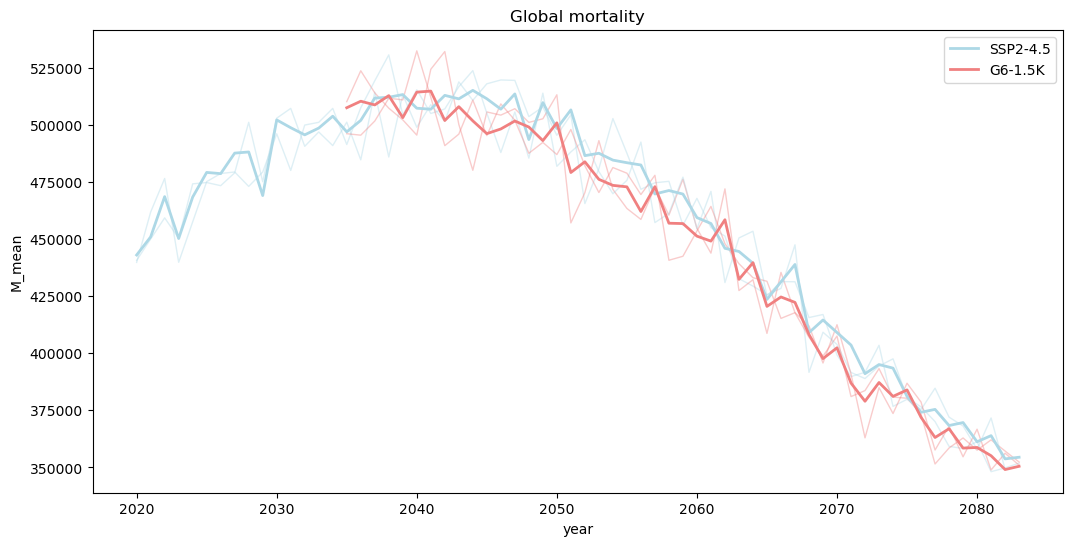

In [12]:
fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=1.5))
for ens_num in range(1, 3):
    da2["M_mean"].sel(ensemble=ens_num).plot(color='lightblue', alpha=0.4, linewidth=1)
    da1["M_mean"].sel(ensemble=ens_num).plot(color='lightcoral', alpha=0.4, linewidth=1)
da2["M_mean"].mean("ensemble").plot(color='lightblue', linewidth=2, label="SSP2-4.5")
da1["M_mean"].mean("ensemble").plot(color='lightcoral', linewidth=2, label="G6-1.5K")
#plt.ylim(0, 700000)
plt.title("Global mortality")
plt.legend()

Text(0.5, 1.0, 'Difference in Global Mortality')

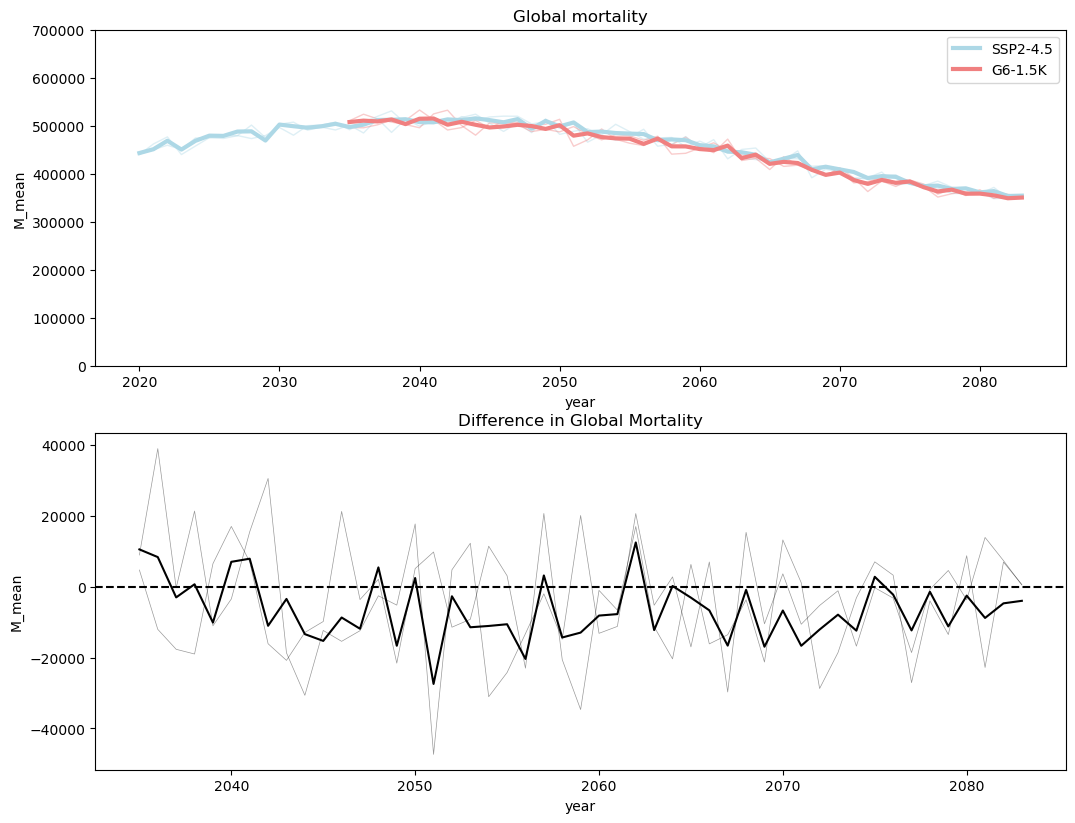

In [11]:
fig = plt.figure(figsize=autosize_figure(2, 1, xscale_factor=1.5))
gs = GridSpec(2, 1)  # rows, columns

ax1 = fig.add_subplot(gs[0, 0])
for ens_num in range(1, 3):
    da2["M_mean"].sel(ensemble=ens_num).plot(color='lightblue', alpha=0.4, linewidth=1)
    da1["M_mean"].sel(ensemble=ens_num).plot(color='lightcoral', alpha=0.4, linewidth=1)
da2["M_mean"].mean("ensemble").plot(color='lightblue', linewidth=3, label="SSP2-4.5")
da1["M_mean"].mean("ensemble").plot(color='lightcoral', linewidth=3, label="G6-1.5K")
plt.ylim(0, 700000)
plt.title("Global mortality")
plt.legend()

ax2 = fig.add_subplot(gs[1, 0])
for ens_num in range(1, 3):
    da["M_mean"].sel(ensemble=ens_num).plot(color='k', alpha=0.4, linewidth=0.5)
da["M_mean"].mean("ensemble").plot(color='k')
plt.axhline(0, color='k', linestyle='--')
plt.title("Difference in Global Mortality")